# Nhận diện tình trạng giao thông từ video MP4

Notebook này lấy mẫu frame từ video camera, phát hiện phương tiện bằng YOLO, vẽ bounding box + track ID, rồi dùng chuyển động của cùng một xe qua ít nhất 3 frame để phân loại: **thông thoáng**, **đông đúc** hoặc **ùn tắc**.

> Đơn vị tốc độ mặc định là pixel/giây. Nếu cần km/h, hãy hiệu chỉnh `METERS_PER_PIXEL` bằng một đoạn đường có chiều dài đã biết trong vùng quan sát.

## 1. Cài thư viện (chạy một lần)

Chọn đúng bản PyTorch CUDA phù hợp driver NVIDIA tại https://pytorch.org/get-started/locally/ nếu môi trường chưa có CUDA.

In [ ]:
%pip install -q ultralytics opencv-python pandas matplotlib
%pip install -q ultralytics opencv-python pandas matplotlib
# Ví dụ CUDA 12.1 (chỉ chạy khi cần cài lại PyTorch):
#%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from collections import defaultdict, deque
from pathlib import Path
import math

import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = 0 if CUDA_AVAILABLE else 'cpu'
USE_HALF = CUDA_AVAILABLE
print(f'Device: {DEVICE}')
if CUDA_AVAILABLE:
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_MEMORY_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {GPU_NAME}')
    print(f'VRAM: {GPU_MEMORY_GB:.1f} GB')
    print(f'CUDA: {torch.version.cuda}')
    torch.backends.cudnn.benchmark = True
else:
    GPU_NAME = 'CPU'
    print('Không có CUDA: notebook chạy trên CPU, nhưng sẽ chậm hơn.')


Device: 0
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 15.9 GB
CUDA: 13.0


## 2. Cấu hình đầu vào và ngưỡng nghiệp vụ

Đặt video MP4 vào `data/traffic.mp4` hoặc sửa `VIDEO_PATH`. `SAMPLE_FPS` là tốc độ lấy mẫu; ví dụ 5 FPS nghĩa là chỉ suy luận khoảng 1 trong mỗi 6 frame của video 30 FPS, giúp giảm tải GPU/CPU.

In [2]:
# Mỗi camera có một mã và ROI riêng. Toạ độ được chuẩn hoá 0..1 nên vẫn đúng
# khi video được đổi độ phân giải. Thay các điểm mẫu dưới đây bằng lòng đường thực tế.
CAMERA_ID = "camera_02"
VIDEO_PATH = Path(r"C:\Users\ADMIN\Downloads\traffic congestion detection\data\YTSave_YouTube_Camera-duong-pho-013_Media_HIIO0FuuYjI_001_1080p.mp4")
OUTPUT_PATH = Path(r"C:\Users\ADMIN\Downloads\traffic congestion detection\outputs\traffic_annotated4.mp4")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

ROI_BY_CAMERA = {
    # (x / frame_width, y / frame_height); chỉnh sau khi chạy cell xem ROI bên dưới.
    "hanoi_rush_hour_001": [(0.03, 0.38), (0.97, 0.31), (0.99, 0.98), (0.01, 0.98)],
    # Ví dụ camera thứ hai: thêm VIDEO_PATH tương ứng rồi vẽ/điền polygon riêng.
    "camera_02": [(0.2, 0.15), (0.3, 0.15), (1.00, 0.75), (1.00, 0.98), (0.01, 0.98)],
}

MODEL_NAME = "yolo11l.pt"
SAMPLE_FPS = 5.0
CONFIDENCE = 0.25  # hạ nhẹ để audit các xe máy nhỏ; tăng lại nếu quá nhiều false positive
IMGSZ = 960
VEHICLE_CLASS_IDS = {1, 2, 3, 5, 7}  # bicycle, car, motorcycle, bus, truck (COCO)
MOTORCYCLE_CLASS_ID = 3

START_TIME_S = 0
DURATION_S = 120  # None = từ START_TIME_S đến hết video

# Vận tốc đang tính theo px/s nếu METERS_PER_PIXEL=None. Ngưỡng dưới phải được
# hiệu chỉnh theo góc camera; dùng m/s chỉ khi đã đo được tỷ lệ pixel-thực tế.
METERS_PER_PIXEL = None
MOVING_SPEED_THRESHOLD = 12.0  # px/s (hoặc m/s nếu METERS_PER_PIXEL được đặt)
MIN_TRACK_POINTS = 3
TRACK_HISTORY = 20
TEMPORAL_WINDOW_S = 3.0        # cửa sổ chống nhấp nháy trạng thái
MIN_STATE_SAMPLES = 3

CROWDED_COUNT = 8
JAM_COUNT = 12
CROWDED_SPEED = 30.0
JAM_SPEED = 12.0

# Audit detector trước tracker: lấy mẫu ít frame để kiểm tra xe máy bị bỏ sót.
AUDIT_SAMPLE_COUNT = 12
AUDIT_OUTPUT_PATH = OUTPUT_PATH.with_name("detector_roi_audit.jpg")

assert CAMERA_ID in ROI_BY_CAMERA, f"Chưa có ROI cho camera: {CAMERA_ID}"
assert START_TIME_S >= 0
assert DURATION_S is None or DURATION_S > 0
assert VIDEO_PATH.exists(), f"Không tìm thấy: {VIDEO_PATH.resolve()}"


## 3. Hiệu chỉnh và vẽ ROI theo camera

ROI được lưu theo tỷ lệ khung hình trong `ROI_BY_CAMERA`. Chạy cell dưới để xem polygon phủ lòng đường; chỉnh bốn hay nhiều điểm của camera đang dùng trong cell cấu hình, sau đó chạy lại. Chỉ tâm bounding box nằm trong polygon mới được tính.


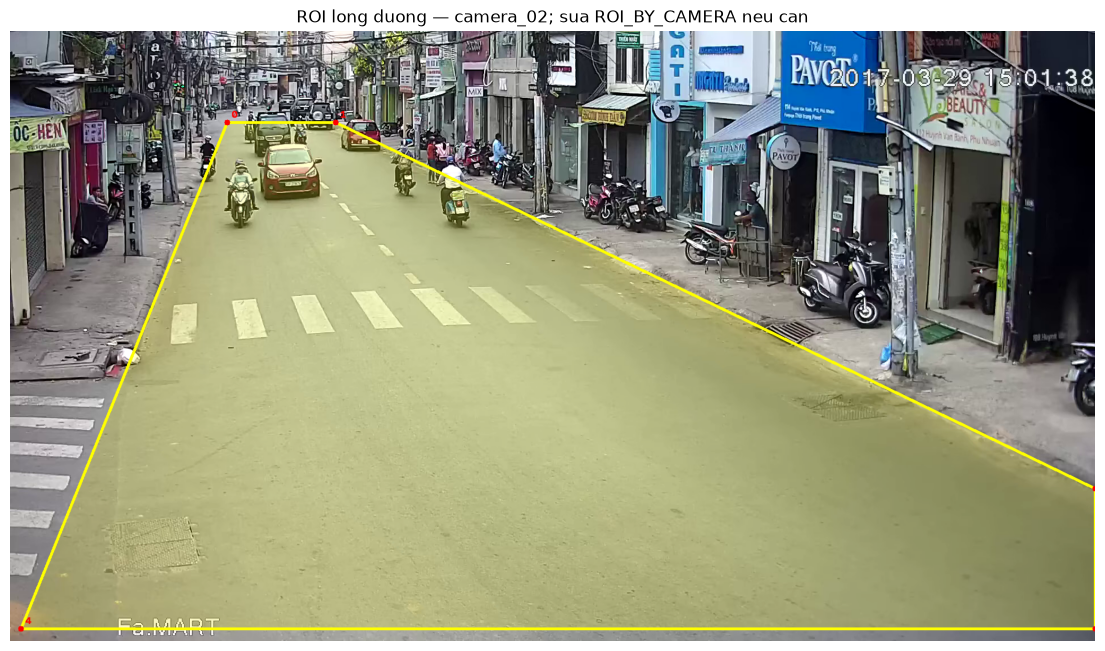

In [3]:
def roi_polygon(camera_id, frame_width, frame_height):
    """Chuyển các đỉnh ROI chuẩn hoá của từng camera sang pixel."""
    points = ROI_BY_CAMERA[camera_id]
    return np.array(
        [(round(x * frame_width), round(y * frame_height)) for x, y in points],
        dtype=np.int32,
    )


def inside_roi(point, polygon):
    x, y = point
    return cv2.pointPolygonTest(
        polygon.astype(np.int32),
        (int(x), int(y)),
        False,
    ) >= 0


def show_roi_preview(video_path, camera_id, time_s=0):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_MSEC, time_s * 1000)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError("Không đọc được frame để xem ROI.")
    polygon = roi_polygon(camera_id, frame.shape[1], frame.shape[0])
    preview = frame.copy()
    overlay = preview.copy()
    cv2.fillPoly(overlay, [polygon], (0, 255, 255))
    cv2.addWeighted(overlay, 0.20, preview, 0.80, 0, preview)
    cv2.polylines(preview, [polygon], True, (0, 255, 255), 3)
    for index, (x, y) in enumerate(polygon):
        cv2.circle(preview, (x, y), 5, (0, 0, 255), -1)
        cv2.putText(preview, str(index), (x + 8, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
    plt.title(f"ROI long duong — {camera_id}; sua ROI_BY_CAMERA neu can")
    plt.axis("off")
    plt.show()


show_roi_preview(VIDEO_PATH, CAMERA_ID, START_TIME_S)


## 4. Kiểm tra detector độc lập trước khi tracking

Cell này gọi `model.predict` (không dùng tracker), lọc theo ROI, rồi lưu ảnh audit. Kiểm tra trực quan các xe máy trong ảnh; nếu còn bỏ sót, thử tăng `IMGSZ`, giảm `CONFIDENCE` từng bước nhỏ hoặc dùng model lớn hơn trước khi đánh giá ByteTrack.


Model: yolo11l.pt | device=0 | half=True
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' 

,time_s,vehicles_in_roi,motorcycles_in_roi
0,0.00,7,3
1,2.96,8,5
2,5.96,8,5
3,8.96,9,6
4,11.92,5,3
5,14.92,2,1
6,17.92,2,1
7,20.92,3,2
8,23.88,5,4
9,26.88,9,8


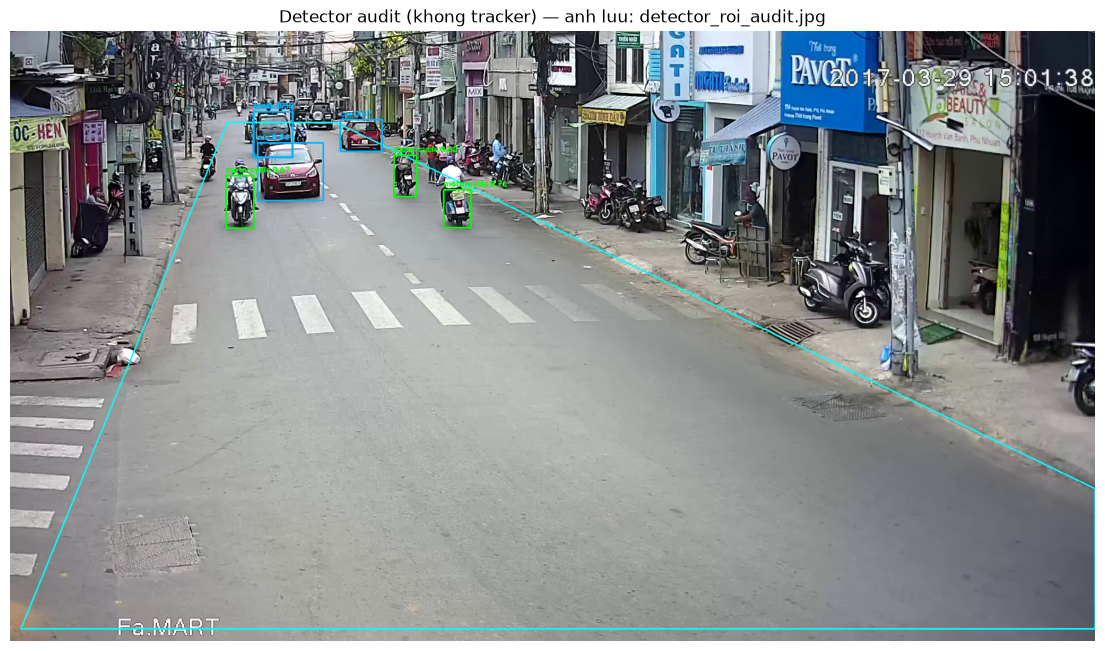

In [4]:
def detections_in_roi(result, polygon):
    """Trả về detection thô của YOLO có tâm nằm trong ROI, không phụ thuộc tracker."""
    detections = []
    if result.boxes is None:
        return detections
    xyxy = result.boxes.xyxy.cpu().numpy().astype(int)
    classes = result.boxes.cls.int().cpu().tolist()
    confidences = result.boxes.conf.cpu().numpy().tolist()
    for box, class_id, confidence in zip(xyxy, classes, confidences):
        x1, y1, x2, y2 = box
        center = (int(x1 + x2) // 2, int(y1 + y2) // 2)
        if inside_roi(center, polygon):
            detections.append((box, class_id, float(confidence)))
    return detections


def audit_detector(model, video_path, camera_id, sample_count=AUDIT_SAMPLE_COUNT):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    polygon = roi_polygon(camera_id, width, height)
    start = min(round(START_TIME_S * fps), max(frame_count - 1, 0))
    stop = frame_count if DURATION_S is None else min(frame_count, start + round(DURATION_S * fps))
    frame_numbers = np.linspace(start, max(start, stop - 1), min(sample_count, max(stop - start, 1)), dtype=int)
    rows, example = [], None
    for frame_number in np.unique(frame_numbers):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_number))
        ok, frame = cap.read()
        if not ok:
            continue
        result = model.predict(frame, classes=list(VEHICLE_CLASS_IDS), conf=CONFIDENCE, imgsz=IMGSZ,
                               device=DEVICE, half=USE_HALF, verbose=False)[0]
        detections = detections_in_roi(result, polygon)
        motorcycle_count = sum(class_id == MOTORCYCLE_CLASS_ID for _, class_id, _ in detections)
        rows.append({"time_s": round((frame_number - start) / fps, 2), "vehicles_in_roi": len(detections),
                     "motorcycles_in_roi": motorcycle_count})
        if example is None:
            example = frame.copy()
            cv2.polylines(example, [polygon], True, (255, 255, 0), 2)
            for box, class_id, confidence in detections:
                x1, y1, x2, y2 = box
                color = (0, 255, 0) if class_id == MOTORCYCLE_CLASS_ID else (255, 180, 0)
                cv2.rectangle(example, (x1, y1), (x2, y2), color, 2)
                cv2.putText(example, f"{result.names[class_id]} {confidence:.2f}", (x1, max(20, y1 - 5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    cap.release()
    audit_df = pd.DataFrame(rows)
    if example is not None:
        cv2.imwrite(str(AUDIT_OUTPUT_PATH), example)
    return audit_df, example


model = YOLO(MODEL_NAME)
if USE_HALF:
    model.model.half()
print(f'Model: {MODEL_NAME} | device={DEVICE} | half={USE_HALF}')
detector_audit_df, detector_audit_frame = audit_detector(model, VIDEO_PATH, CAMERA_ID)
display(detector_audit_df)
if detector_audit_frame is not None:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(detector_audit_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Detector audit (khong tracker) — anh luu: {AUDIT_OUTPUT_PATH.name}")
    plt.axis("off")
    plt.show()


## 5. Tracking, tỷ lệ xe chạy/dừng và temporal smoothing

Vận tốc chỉ dùng các điểm track ở trong ROI. Mỗi xe được gán chạy/dừng theo đa số mẫu trong cửa sổ `TEMPORAL_WINDOW_S`; trạng thái giao thông cũng dùng đa số trong cùng cửa sổ để tránh đổi trạng thái vì một frame đơn lẻ.


In [6]:
def prune_window(history, now_s, window_s):
    while history and now_s - history[0][0] > window_s:
        history.popleft()


def track_speed(history):
    if len(history) < MIN_TRACK_POINTS:
        return None
    t0, x0, y0 = history[0]
    t1, x1, y1 = history[-1]
    elapsed = t1 - t0
    if elapsed <= 0:
        return None
    speed = math.hypot(x1 - x0, y1 - y0) / elapsed
    return speed * METERS_PER_PIXEL if METERS_PER_PIXEL else speed


def stable_motion_state(state_history, now_s):
    prune_window(state_history, now_s, TEMPORAL_WINDOW_S)
    if len(state_history) < MIN_STATE_SAMPLES:
        return None
    return sum(is_moving for _, is_moving in state_history) / len(state_history) >= 0.5


def raw_traffic_status(vehicle_count, moving_ratio, mean_speed):
    if vehicle_count >= JAM_COUNT and moving_ratio <= 0.25 and mean_speed < JAM_SPEED:
        return "UN TAC", (0, 0, 255)
    if vehicle_count >= CROWDED_COUNT or (vehicle_count > 5 and moving_ratio <= 0.55 and mean_speed < CROWDED_SPEED):
        return "DONG DUC", (0, 165, 255)
    return "THONG THOANG", (0, 180, 0)


def smooth_status(status_history, now_s):
    prune_window(status_history, now_s, TEMPORAL_WINDOW_S)
    labels = [label for _, label in status_history]
    # ưu tiên trạng thái mới nhất khi số phiếu bằng nhau
    label = max(set(labels), key=lambda item: (labels.count(item), max(i for i, value in enumerate(labels) if value == item)))
    colors = {"UN TAC": (0, 0, 255), "DONG DUC": (0, 165, 255), "THONG THOANG": (0, 180, 0)}
    return label, colors[label]


def draw_label(frame, text, origin, color, scale=0.65):
    (w, h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, 2)
    x, y = origin
    cv2.rectangle(frame, (x, y - h - baseline - 6), (x + w + 8, y + 4), color, -1)
    cv2.putText(frame, text, (x + 4, y - 4), cv2.FONT_HERSHEY_SIMPLEX, scale, (255, 255, 255), 2, cv2.LINE_AA)


cap = cv2.VideoCapture(str(VIDEO_PATH))
source_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
ROI_POLYGON = roi_polygon(CAMERA_ID, width, height)
start_frame = min(round(START_TIME_S * source_fps), total_frames)
end_frame = total_frames if DURATION_S is None else min(start_frame + round(DURATION_S * source_fps), total_frames)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
frame_stride = max(1, round(source_fps / SAMPLE_FPS))
writer = cv2.VideoWriter(str(OUTPUT_PATH), cv2.VideoWriter_fourcc(*"mp4v"), source_fps, (width, height))

position_histories = defaultdict(deque)
motion_histories = defaultdict(deque)
status_history = deque()
metrics, last_boxes = [], []
last_summary = {"status": "DANG KHOI TAO", "color": (100, 100, 100), "mean_speed": 0.0, "moving": 0, "stopped": 0, "unknown": 0}
frame_index = start_frame

try:
    while frame_index < end_frame:
        ok, frame = cap.read()
        if not ok:
            break
        timestamp_s = (frame_index - start_frame) / source_fps
        if (frame_index - start_frame) % frame_stride == 0:
            result = model.track(frame, persist=True, tracker="bytetrack.yaml", classes=list(VEHICLE_CLASS_IDS),
                                 conf=CONFIDENCE, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
            last_boxes, speeds, moving, stopped, unknown = [], [], 0, 0, 0
            if result.boxes is not None and result.boxes.id is not None:
                xyxy = result.boxes.xyxy.cpu().numpy().astype(int)
                ids = result.boxes.id.int().cpu().tolist()
                for box, track_id in zip(xyxy, ids):
                    x1, y1, x2, y2 = box
                    center = ((x1 + x2) // 2, (y1 + y2) // 2)
                    if not inside_roi(center, ROI_POLYGON):
                        continue
                    history = position_histories[track_id]
                    history.append((timestamp_s, *center))
                    prune_window(history, timestamp_s, TEMPORAL_WINDOW_S)
                    speed = track_speed(history)
                    if speed is not None:
                        speeds.append(speed)
                        motion_histories[track_id].append((timestamp_s, speed >= MOVING_SPEED_THRESHOLD))
                    state = stable_motion_state(motion_histories[track_id], timestamp_s)
                    if state is True:
                        moving += 1
                    elif state is False:
                        stopped += 1
                    else:
                        unknown += 1
                    last_boxes.append((box, track_id, speed, state))
            classified = moving + stopped
            moving_ratio = moving / classified if classified else 0.0
            stopped_ratio = stopped / classified if classified else 0.0
            mean_speed = float(np.mean(speeds)) if speeds else 0.0
            raw_label, _ = raw_traffic_status(len(last_boxes), moving_ratio, mean_speed)
            status_history.append((timestamp_s, raw_label))
            status, color = smooth_status(status_history, timestamp_s)
            last_summary = {"status": status, "color": color, "mean_speed": mean_speed, "moving": moving,
                            "stopped": stopped, "unknown": unknown, "moving_ratio": moving_ratio, "stopped_ratio": stopped_ratio}
            metrics.append({"time_s": round(timestamp_s, 2), "vehicle_count_roi": len(last_boxes),
                            "moving_count": moving, "stopped_count": stopped, "unclassified_count": unknown,
                            "moving_ratio": moving_ratio, "stopped_ratio": stopped_ratio, "mean_speed": mean_speed,
                            "raw_status": raw_label, "smoothed_status": status})

        annotated = frame.copy()
        overlay = annotated.copy()
        cv2.fillPoly(overlay, [ROI_POLYGON], (255, 255, 0))
        cv2.addWeighted(overlay, 0.12, annotated, 0.88, 0, annotated)
        cv2.polylines(annotated, [ROI_POLYGON], True, (255, 255, 0), 2)
        for (x1, y1, x2, y2), track_id, speed, state in last_boxes:
            color = (0, 220, 0) if state is True else ((0, 0, 255) if state is False else (180, 180, 180))
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            unit = "m/s" if METERS_PER_PIXEL else "px/s"
            state_text = "chay" if state is True else ("dung" if state is False else "dang do")
            speed_text = "warming up" if speed is None else f"{speed:.1f} {unit}"
            draw_label(annotated, f"ID {track_id} | {state_text} | {speed_text}", (x1, max(25, y1)), color, 0.42)
        draw_label(annotated, f"{last_summary['status']} | ROI xe: {len(last_boxes)} | chay: {last_summary['moving_ratio']:.0%} | dung: {last_summary['stopped_ratio']:.0%}", (15, 45), last_summary["color"], 0.62)
        draw_label(annotated, f"Toc do TB: {last_summary['mean_speed']:.1f} | cua so: {TEMPORAL_WINDOW_S:.1f}s", (15, 82), (80, 80, 80), 0.52)
        writer.write(annotated)
        frame_index += 1
finally:
    cap.release()
    writer.release()

metrics_df = pd.DataFrame(metrics)
print(f"Da luu video: {OUTPUT_PATH.resolve()}")
display(metrics_df.tail(10))


Da luu video: C:\Users\ADMIN\Downloads\traffic congestion detection\outputs\traffic_annotated4.mp4


,time_s,vehicle_count_roi,moving_count,stopped_count,unclassified_count,moving_ratio,stopped_ratio,mean_speed,raw_status,smoothed_status
155,31.0,8,4,2,2,0.666667,0.333333,57.663923,DONG DUC,DONG DUC
156,31.2,9,6,2,1,0.750000,0.250000,68.735823,DONG DUC,DONG DUC
157,31.4,8,6,2,0,0.750000,0.250000,62.478576,DONG DUC,DONG DUC
158,31.6,8,6,2,0,0.750000,0.250000,68.257970,DONG DUC,DONG DUC
159,31.8,7,5,2,0,0.714286,0.285714,58.053487,THONG THOANG,DONG DUC
160,32.0,7,5,2,0,0.714286,0.285714,61.708857,THONG THOANG,DONG DUC
161,32.2,8,5,2,1,0.714286,0.285714,66.797030,DONG DUC,DONG DUC
162,32.4,8,5,2,1,0.714286,0.285714,67.610457,DONG DUC,DONG DUC
163,32.6,8,5,2,1,0.714286,0.285714,64.017954,DONG DUC,DONG DUC
164,32.8,8,5,2,1,0.714286,0.285714,66.616760,DONG DUC,DONG DUC


## 6. Tổng hợp kết quả

`moving_ratio` và `stopped_ratio` chỉ tính các track đã đủ mẫu trong cửa sổ temporal. Khi thay camera, luôn thêm ROI mới vào `ROI_BY_CAMERA`, xem preview và chạy audit detector trước khi chạy cell tracking.


In [7]:
if not metrics_df.empty:
    display(metrics_df.groupby("smoothed_status").agg(
        samples=("smoothed_status", "size"),
        mean_vehicles_in_roi=("vehicle_count_roi", "mean"),
        mean_moving_ratio=("moving_ratio", "mean"),
        mean_stopped_ratio=("stopped_ratio", "mean"),
        mean_speed=("mean_speed", "mean"),
    ).round(3))

from IPython.display import Video, display
display(Video(str(OUTPUT_PATH), embed=False, width=900))


,samples,mean_vehicles_in_roi,mean_moving_ratio,mean_stopped_ratio,mean_speed
smoothed_status,,,,,
DONG DUC,13,8.077,0.686,0.237,61.323
THONG THOANG,152,4.546,0.608,0.366,39.525
